# **Strata Analytics Data Scraping Project**

By: Fernando Cortés Rentería

The goal of the following code is to manage the data from various different sources and to use the resulting
data model to answer the question: "does this house need a roof change?"

## Initial Data Loading

### Downloading libraries and configuring Pandas

In [1]:
import pandas as pd

# I import and configure pandas display options
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.width', 120)          # Wider output
pd.set_option("display.precision", 2)
pd.set_option('display.float_format', '{:,.2f}'.format)

### Creating Florida Dataset from Broward and Miami-Dade County Parcel info

In [2]:
broward = pd.read_csv('broward_parcels.csv')
miami = pd.read_csv('miamidade_parcels.csv')

In [3]:
# i add county identifier
miami['county'] = 'Miami-Dade'
broward['county'] = 'Broward'

In [4]:
# merge into a single dataframe
florida_df = pd.concat([broward, miami], ignore_index=True)
florida_df.rename(columns={'parcel_id': 'ParcelID'}, inplace=True)

In [ ]:
'''filter for residential properties (DOR_UC codes 1-4):
    1 - Single Family Residential
    2 - Mobile Home
    3 - Condominium
    4 - Cooperative'''


florida_residential = florida_df[florida_df['property_use'] <= 4]

### Pre-cleaning Roof Permit Datasets

#### Tamarac

In [ ]:
tamarac_permits = pd.read_csv(r'./Tamarac/Tamarac_cleaned.csv')
tamarac_permits["Applied Date"] = pd.to_datetime(tamarac_permits["Applied Date"], format='mixed')

#### Pompano

In [6]:
# pompano permits
pompano_permits = pd.read_json('resultadosPopmano.json')
pompano_permits['Applied Date'] = pd.to_datetime(pompano_permits['application_date'], format='mixed')

pompano_permits['parcel_id'] = pompano_permits['parcel_id'].str.replace('-','')

pompano_cleaned = pompano_permits.rename(columns={
    'parcel_id': 'ParcelID',
    'application_status': 'Status',
    'application_type': 'WorkType',
    'general_contractor': 'Contractor'
})[['ParcelID', 'WorkType', 'Contractor', 'Status', 'Applied Date']]

pompano_cleaned['Contractor'].fillna('Unknown', inplace=True)

In [7]:
pompano_cleaned

,ParcelID,WorkType,Contractor,Status,Applied Date
0,920501217001133,B-*ROOF RE-ROOF,M & L ROOFING & CONSTRUCTION,CLOSED,1999-12-29
1,83311773000541,B-*ROOF RE-ROOF,SOLAR SHIELD URETHANE ROOF SYS,CLOSED,1999-12-29
2,832905119003202,B-*ROOF RE-ROOF,A B C ROOFING CORP,CLOSED,1999-12-27
3,8330135001600,B-*ROOF RE-ROOF,EVANS BROTHERS ROOFING INC,CLOSED,1999-12-27
4,823623EFFLUE001799,B-ADDC ADD NON-RESIDENTIAL,R J SULLIVAN CORPORATION,OPEN PERMITS,1999-12-23
...,...,...,...,...,...
994,822609712002100,B-*ROOF RE-ROOF,LEWIS ROOFING,CLOSED,1998-06-23
995,920131G37000191,B-*ROOF RE-ROOF,HURRICANE ROOFING CORP,CLOSED,1998-06-23
996,92020018807T800063118,B-A+AM ADD + ALT MULTI FAM,M P L CONSTRUCTION INC,CERTIFICATE ISSUED,1998-06-22
997,822807PARCEL003201,B-*ROOF RE-ROOF,ROOFING SYSTEMS INC OF PBC,CLOSED,1998-06-19


#### Hallandale Beach

In [8]:
hallandale_beach_permits = pd.read_csv('Hallandale_beach.csv')
hallandale_cleaned = hallandale_beach_permits.rename(columns={
    'Main Parcel': 'ParcelID',
    'Type': 'WorkType',
    'Company Name': 'Contractor'
})[['ParcelID', 'WorkType', 'Contractor', 'Status', 'Applied Date']]
hallandale_cleaned['Applied Date'] = pd.to_datetime(hallandale_cleaned['Applied Date'], format='%m/%d/%Y')
hallandale_cleaned['Contractor'].fillna('Unknown', inplace=True)

#### Pembroke Pines

In [9]:
# pembroke pines requires data cleaning

# it has no parcel id column, so we will merge on address later

pembroke_pines_permits = pd.read_csv('roof_pembroke.csv')

pembroke_cleaned = pembroke_pines_permits.rename(columns={
    'Type': 'WorkType',
})[['Address', 'WorkType', 'Status', 'Applied Date']]
pembroke_cleaned['Applied Date'] = pd.to_datetime(pembroke_cleaned['Applied Date'], format='%m/%d/%Y')
pembroke_cleaned['Contractor'] = 'Unknown'

In [10]:
pembroke_cleaned

,Address,WorkType,Status,Applied Date,Contractor
0,16131 NW 15 ST,Residential Revision,Complete,2023-01-17,Unknown
1,101 121 SW 184 PL,Residential Revision,Complete,2025-01-23,Unknown
2,125 145 SW 184,Residential Revision,Complete,2025-01-28,Unknown
3,1328 NW 159 AVE,Residential Revision,Complete,2025-10-09,Unknown
4,1550 NW 78 AVE,Residential Revision,Complete,2025-10-30,Unknown
...,...,...,...,...,...
673,7641 NW 13 st,Residential Re-Roofing,Complete,2016-05-04,Unknown
674,20117 SW 54 Pl,Residential Re-Roofing,Complete,2016-05-05,Unknown
675,9831 SW 16 ct,Residential Re-Roofing,Complete,2010-08-26,Unknown
676,1491 NW 113 Ave,Residential Re-Roofing,Complete,2016-05-05,Unknown


### Joining Datasets

#### Permits

In [11]:
permits = pd.concat([tamarac_permits, hallandale_cleaned, pompano_cleaned], ignore_index=True)

In [12]:
permits

,ParcelID,WorkType,Contractor,Status,Applied Date
0,494111100371,REROOF SHINGLES,A & A ROOFING CONTRACTORS INC,CLOSED,2017-06-01
1,494104670224,REROOF SHINGLES ONLY,A & J ROOFING CORP,CLOSED,2016-02-03
2,494103050230,SEE 19-242 REROOF FLAT,A & J ROOFING CORP,DUPLICATE,2019-01-16
3,494103050230,REROOF FLAT,A & J ROOFING CORP,CLOSED,2019-01-16
4,494113100880,RE-ROOF SHINGLE & FLAT,A & J ROOFING CORP,APPROVED,2022-04-11
...,...,...,...,...,...
2993,822609712002100,B-*ROOF RE-ROOF,LEWIS ROOFING,CLOSED,1998-06-23
2994,920131G37000191,B-*ROOF RE-ROOF,HURRICANE ROOFING CORP,CLOSED,1998-06-23
2995,92020018807T800063118,B-A+AM ADD + ALT MULTI FAM,M P L CONSTRUCTION INC,CERTIFICATE ISSUED,1998-06-22
2996,822807PARCEL003201,B-*ROOF RE-ROOF,ROOFING SYSTEMS INC OF PBC,CLOSED,1998-06-19


In [13]:
permits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2998 entries, 0 to 2997
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ParcelID      2992 non-null   object        
 1   WorkType      2945 non-null   object        
 2   Contractor    2998 non-null   object        
 3   Status        2998 non-null   object        
 4   Applied Date  2998 non-null   datetime64[ns]
dtypes: datetime64[ns](1), object(4)
memory usage: 117.2+ KB


#### Main df creation

In [14]:
df = pd.merge(permits, florida_residential, left_on='ParcelID', right_on='ParcelID', how='inner')

#### Pembroke Pines df merge

In [15]:
def match_address(addr):
    # Find the first full address in florida_residential that starts with this prefix
    matches = florida_residential[florida_residential["situs_address"].str.startswith(addr)]
    if not matches.empty:
        return matches.iloc[0]["situs_address"]   # return the full address
    return None

pembroke_cleaned["situs_address"] = pembroke_cleaned["Address"].apply(match_address)

In [16]:
pembroke_cleaned = pembroke_cleaned[pembroke_cleaned["situs_address"].notnull()]

In [18]:
df_pembroke = pd.merge(pembroke_cleaned, florida_residential, left_on='situs_address', right_on='situs_address', how='inner')

In [19]:
df_pembroke.set_index('ParcelID', inplace=True)
df_pembroke.drop('Address', axis=1, inplace=True)

In [20]:
df = pd.concat([df, df_pembroke], ignore_index=True)

-----
## Main Data Pre-Processing

### Visualizing Data

In [21]:
df

,ParcelID,WorkType,Contractor,Status,Applied Date,situs_address,year_built,county_code,property_use,lot_size,building_area,land_value,just_value,county
0,494111100371,REROOF SHINGLES,A & A ROOFING CONTRACTORS INC,CLOSED,2017-06-01,"6195 LAUREL LN ##B, TAMARAC 33319",1981,16,1,2385,2378,"9,540.00","381,120.00",Broward
1,494104670224,REROOF SHINGLES ONLY,A & J ROOFING CORP,CLOSED,2016-02-03,"7182 WOODMONT WAY, TAMARAC 33321",1990,16,1,2298,1708,"34,470.00","407,000.00",Broward
2,494113100880,RE-ROOF SHINGLE & FLAT,A & J ROOFING CORP,APPROVED,2022-04-11,"4907 NW 55 ST, TAMARAC 33319",1969,16,1,4173,1078,"12,520.00","257,470.00",Broward
3,494104AB0210,REROOF FLAT ONLY,A & M FOX ROOFING,CLOSED,2014-06-05,"7808 BEECHFERN CIR #21, TAMARAC 33321",1980,16,4,3345,1684,0.00,"366,720.00",Broward
4,494106012240,REROOF TILE AND FLAT,A & M FOX ROOFING,CLOSED,2014-10-24,"7000 NW 103 AVE, TAMARAC 33321",1979,16,1,10035,2086,"50,150.00","445,640.00",Broward
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,NaN,Residential Re-Roofing,Unknown,Complete,2010-08-24,"6910 SW 12 ST, PEMBROKE PINES 33023",1958,16,1,6361,1385,"22,260.00","408,060.00",Broward
1461,NaN,Residential Re-Roofing,Unknown,Complete,2016-04-26,"9978 NW 10 ST #1, PEMBROKE PINES 33024",1980,16,4,0,1080,0.00,"291,620.00",Broward
1462,NaN,Residential Re-Roofing,Unknown,Complete,2010-08-25,"632 SW 158 TER, PEMBROKE PINES 33027",1994,16,1,2502,1492,"30,020.00","466,860.00",Broward
1463,NaN,Residential Re-Roofing,Unknown,Complete,2016-04-27,"1100 NW 79 WAY, PEMBROKE PINES 33024",1966,16,1,7250,1598,"43,500.00","505,750.00",Broward


### Normalization and Encoding

In [22]:
pd.set_option('display.max_rows', 20)
df['WorkType'].value_counts()

WorkType
BD Roofing - Res - Replace    296
Residential Re-Roofing         67
Building Roofing - Combo       62
BD Roofing - Com - Replace     58
REROOF SHINGLE AND FLAT        38
                             ... 
BD Roofing - Res - New          1
EXP - SEE NEW #09-2872          1
SEE-20-1387                     1
GREENBERG/RE-ROOF               1
REROOF TILE 2900                1
Name: count, Length: 528, dtype: int64

In [23]:
def normalize_material(work_type: str) -> str:
    # Handle missing or non-string values
    if not isinstance(work_type, str):
        return "Other/Unknown"
    
    wt = work_type.upper()

    # Check for shingles
    has_shingle = "SHINGLE" in wt or "SHINGLES" in wt
    # Check for tile
    has_tile = "TILE" in wt or "TILES" in wt
    # Check for flat
    has_flat = "FLAT" in wt
    # Check for metal
    has_metal = "METAL" in wt

    # Assign categories
    if has_shingle and has_tile:
        return "Shingle + Tile"
    elif has_shingle and has_flat:
        return "Shingle + Flat"
    elif has_tile and has_flat:
        return "Tile + Flat"
    elif has_shingle:
        return "Shingle"
    elif has_tile:
        return "Tile"
    elif has_flat:
        return "Flat"
    elif has_metal:
        return "Metal"
    else:
        return "Other/Unknown"

df['Roof_Material'] = df['WorkType'].apply(normalize_material)
df['Roof_Material'].value_counts()

Roof_Material
Other/Unknown     922
Shingle           142
Shingle + Flat    111
Tile              110
Flat               98
Tile + Flat        74
Shingle + Tile      5
Metal               3
Name: count, dtype: int64

### Feature Engineering

New variables:

Integers:
* 'Time Since Last Permit': Counts the amount of days that a parcel has had the same roof without any new permits.

Booleans:
* 'multiple_re_roofs': Identifies duplicated parcel IDs, which signal a house requiring a roof repair or a re-roofing more than once.
* 'too_close': Identifies permits taken within 0 or 1 days of each other for the same parcel, likely due to bureacracy.
* 'after_hurricane': Identifies permits that were taken up to 6 months after a hurricane that affected Florida.
* *'needs_roof_change'*: The primary dependent variable that needs to be predicted. Marks any house that has needed a roof change in the past.


In [ ]:
# idenntify the parcels with multiple permits
duplicated_permits = df["ParcelID"].value_counts()[df["ParcelID"].value_counts() > 1]

df['multiple_re_roofs'] = df.groupby("ParcelID")["ParcelID"].transform("count") > 1

df = df.sort_values(by='Applied Date')
df['Time Since Last Permit'] = df.groupby('ParcelID')['Applied Date'].diff().dt.days

df = df[df['year_built'] != 0]

# Convert year_built into a datetime (Jan 1 of that year)
df["year_built"] = pd.to_datetime(df["year_built"].astype(str), format="%Y")

# Compute difference in days between Applied Date and built_date
fill_values = (df["Applied Date"] - df["year_built"]).dt.days

# Fill NaNs in 'Time Since Last Permit' with this difference
df["Time Since Last Permit"] = df["Time Since Last Permit"].fillna(fill_values)

train_df = df[df['multiple_re_roofs'] == True]



In [25]:
avg_time = train_df.loc[train_df['Time Since Last Permit'].notna() & (train_df['Time Since Last Permit'] != 0),
                        'Time Since Last Permit'].mean()

print(f"Average time since last permit (days): {avg_time:.2f}")

Average time since last permit (days): 8916.59


In [26]:
# Defining my primary boolean indicator:

df['too_close'] = df['Time Since Last Permit'].notna() & (df['Time Since Last Permit'] <= 1)


df["needs_roof_change"] = False
mask = df["ParcelID"].duplicated(keep="last") & ~df["too_close"]
df.loc[mask, "needs_roof_change"] = True

In [27]:
df['needs_roof_change'].value_counts()

needs_roof_change
False    1224
True      229
Name: count, dtype: int64

## Initial Data Analysis

### Graphing Relevant Variables

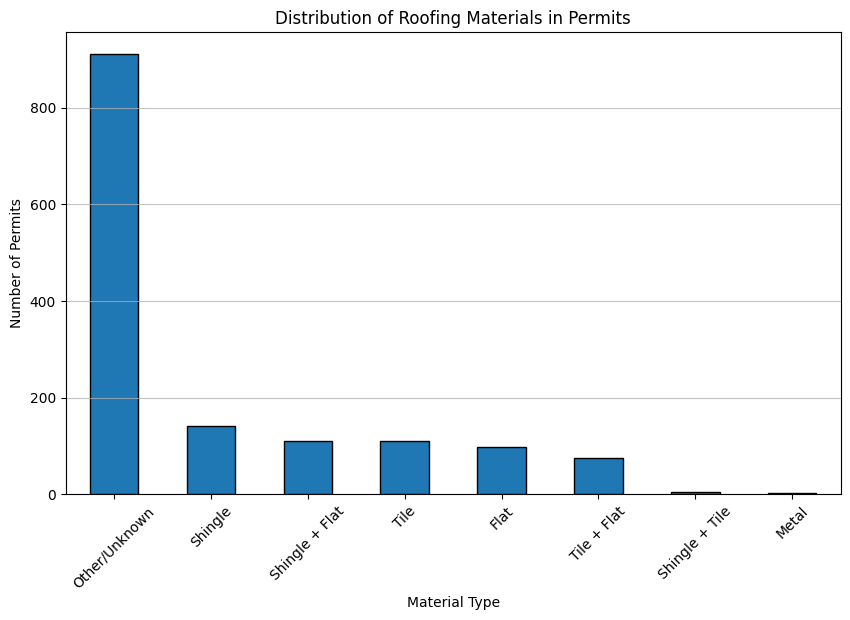

In [28]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Count normalized categories
material_counts = df["Roof_Material"].value_counts()

# Plot
plt.figure(figsize=(10,6))
material_counts.plot(kind="bar", edgecolor="black")
plt.title("Distribution of Roofing Materials in Permits")
plt.xlabel("Material Type")
plt.ylabel("Number of Permits")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.75)
plt.show()


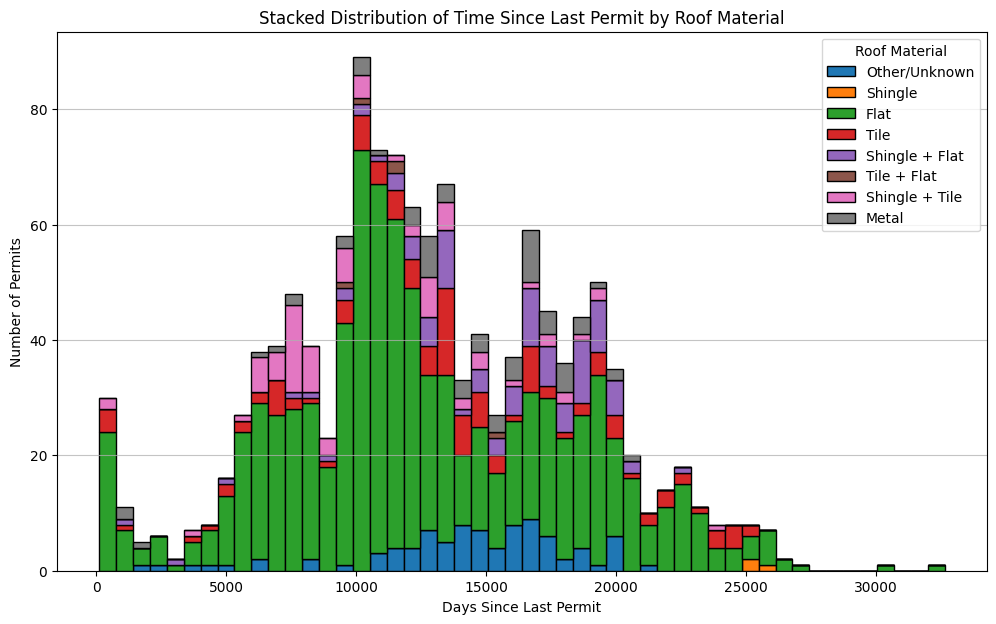

In [29]:
# Filter out NaN and 0 values
data = df[
    df["Time Since Last Permit"].notna() &
    (df["Time Since Last Permit"] > 90)
]

# Prepare the data grouped by roof material
grouped = [
    group["Time Since Last Permit"].values
    for _, group in data.groupby("Roof_Material")
]

labels = data["Roof_Material"].unique()

# Plot stacked histogram
plt.figure(figsize=(12, 7))
plt.hist(grouped, bins=50, stacked=True, label=labels, edgecolor="black")

plt.title("Stacked Distribution of Time Since Last Permit by Roof Material")
plt.xlabel("Days Since Last Permit")
plt.ylabel("Number of Permits")
plt.legend(title="Roof Material")
plt.grid(axis="y", alpha=0.75)
plt.show()

array([[<Axes: title={'center': 'Applied Date'}>,
        <Axes: title={'center': 'Time Since Last Permit'}>],
       [<Axes: title={'center': 'year_built'}>, <Axes: >]], dtype=object)

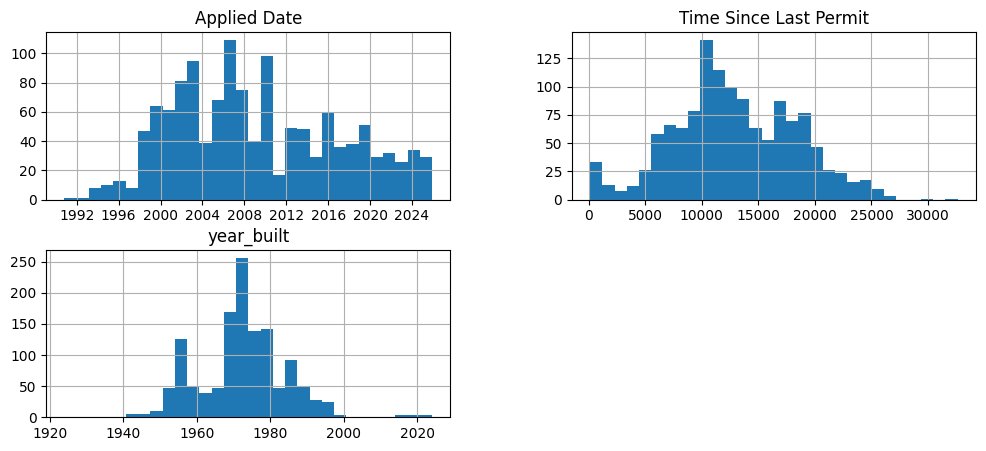

In [140]:
data[['Applied Date', 'Time Since Last Permit', 'year_built']].hist(figsize=(12, 5), bins=30)

### Descriptive Statistics

In [141]:
df.describe()

,Applied Date,year_built,county_code,property_use,lot_size,building_area,land_value,just_value,Time Since Last Permit,year
count,1453,1453,"1,453.00","1,453.00","1,453.00","1,453.00","1,453.00","1,453.00","1,453.00","1,453.00"
mean,2009-12-23 03:41:59.752236800,1973-11-27 23:02:31.135581552,16.00,1.20,"17,448.06","7,325.22","212,207.52","1,639,371.06","11,458.88","1,973.91"
min,1990-10-17 00:00:00,1924-01-01 00:00:00,16.00,1.00,0.00,550.00,0.00,"101,930.00","-10,434.00","1,924.00"
25%,2003-03-26 00:00:00,1968-01-01 00:00:00,16.00,1.00,"4,956.00","1,355.00","21,000.00","339,950.00","7,615.00","1,968.00"
50%,2008-12-23 00:00:00,1973-01-01 00:00:00,16.00,1.00,"6,593.00","1,688.00","33,930.00","418,700.00","11,620.00","1,973.00"
75%,2016-07-05 00:00:00,1980-01-01 00:00:00,16.00,1.00,"8,621.00","2,114.00","50,700.00","530,020.00","16,539.00","1,980.00"
max,2025-12-03 00:00:00,2024-01-01 00:00:00,16.00,4.00,"700,702.00","472,639.00","10,338,220.00","92,675,900.00","32,628.00","2,024.00"
std,NaN,NaN,0.00,0.70,"81,016.25","41,784.61","1,053,077.20","8,111,212.66","6,656.38",13.97


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1453 entries, 1192 to 234
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ParcelID                1379 non-null   object        
 1   WorkType                1403 non-null   object        
 2   Contractor              1453 non-null   object        
 3   Status                  1453 non-null   object        
 4   Applied Date            1453 non-null   datetime64[ns]
 5   situs_address           1453 non-null   object        
 6   year_built              1453 non-null   datetime64[ns]
 7   county_code             1453 non-null   int64         
 8   property_use            1453 non-null   int64         
 9   lot_size                1453 non-null   int64         
 10  building_area           1453 non-null   int64         
 11  land_value              1453 non-null   float64       
 12  just_value              1453 non-null   float64    

## Data Processing

### Further encoding of Roof Materials

In [33]:
df["is_shingle"] = df["Roof_Material"].str.contains("Shingle")
df["is_tile"] = df["Roof_Material"].str.contains("Tile")
df["is_flat"] = df["Roof_Material"].str.contains("Flat")
df['is_metal'] = df["Roof_Material"].str.contains("Metal")
df['is_other'] = ~(df["is_shingle"] | df["is_tile"] | df["is_flat"] | df["is_metal"])

### Correlation Matrix of Predictive Variables

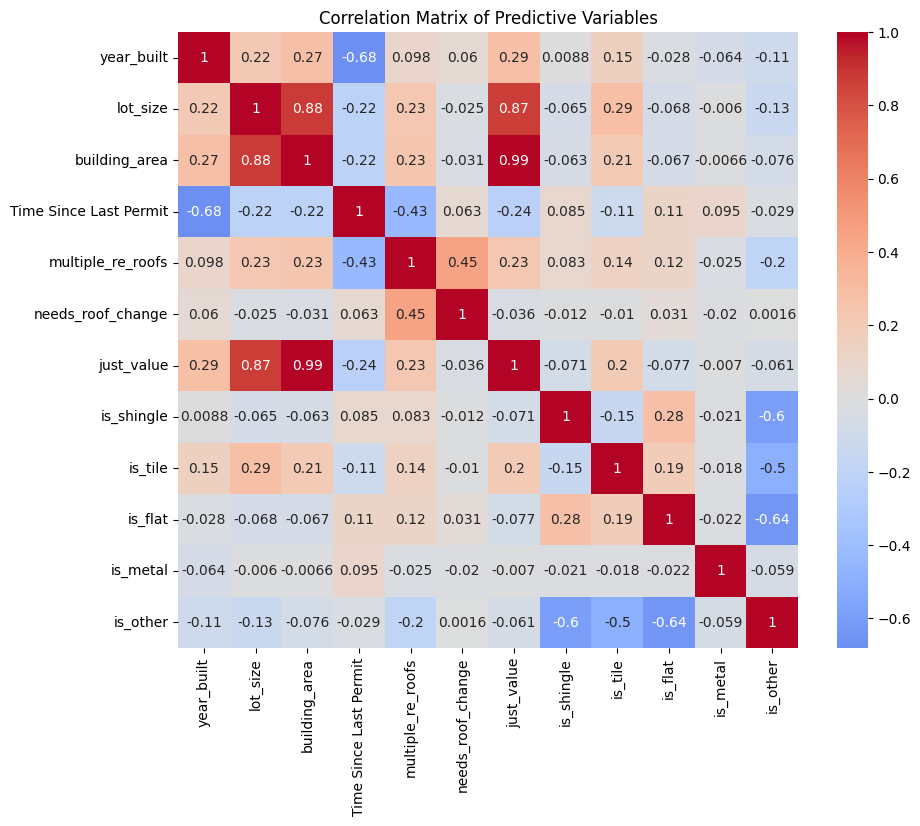

In [142]:
# Select numeric + boolean columns you want to test
candidate_cols = [
    "year_built",
    "lot_size",
    "building_area",
    "Time Since Last Permit",
    "multiple_re_roofs",
    "needs_roof_change",
    "just_value",
    "is_shingle",
    "is_tile",
    "is_flat",
    "is_metal",
    "is_other"
]

# Convert booleans to integers (True=1, False=0) for correlation
df_corr = df[candidate_cols].astype(int)

# Compute correlation matrix
corr_matrix = df_corr.corr()

# Optional: heatmap for visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Predictive Variables")
plt.show()


In [36]:
hurricanes = pd.read_csv('hurricanes_fl.csv')

In [37]:
hurricanes['Date of Impact'] = hurricanes['Date of Impact'].astype(str) + ' ' + hurricanes['Year'].astype(str)

In [38]:
hurricanes['Date of Impact'] = pd.to_datetime(hurricanes['Date of Impact'])

In [39]:
hurricanes.tail(10)

,Storm,Category,Date of Impact,Year,Landfall Winds,Location(s)
39,Dennis,3,2005-07-10,2005,105,Santa Rosa Island
40,Wilma,3,2005-10-24,2005,105,Cape Romano
41,Irma,4,2017-09-10,2017,115,Cudjoe Key
42,Irma,4,2017-09-10,2017,115,Marco Island
43,Michael,5,2018-10-10,2018,140,West of Mexico Beach
44,Ian,4,2022-09-28,2022,130,Cayo Costa
45,Ian,4,2022-09-28,2022,130,Punta Gorda
46,Idalia,3,2023-08-30,2023,100,Keaton Beach
47,Helene,4,2024-09-27,2024,120,Southwest of Perry
48,Milton,3,2024-10-09,2024,100,Siesta Key


In [40]:
df["after_hurricane"] = df["Applied Date"].apply(
    lambda d: any((abs((d - h_date).days) <= 180) for h_date in hurricanes["Date of Impact"])
)

### Correlations

                        Time Since Last Permit  multiple_re_roofs  needs_roof_change  after_hurricane
Time Since Last Permit                    1.00              -0.43               0.06            -0.02
multiple_re_roofs                        -0.43               1.00               0.45             0.12
needs_roof_change                         0.06               0.45               1.00            -0.03
after_hurricane                          -0.02               0.12              -0.03             1.00


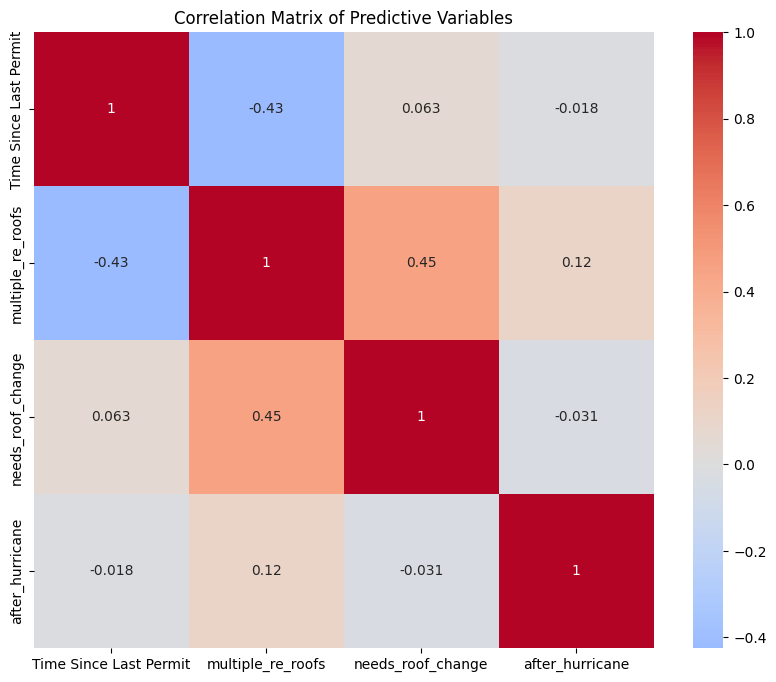

In [41]:
# Select numeric + boolean columns you want to test
candidate_cols = [
    "Time Since Last Permit",
    "multiple_re_roofs",
    "needs_roof_change",
    "after_hurricane"
]

# Convert booleans to integers (True=1, False=0) for correlation
df_corr = df[candidate_cols].astype(int)

# Compute correlation matrix
corr_matrix = df_corr.corr()

# Display nicely
print(corr_matrix)

# Optional: heatmap for visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Predictive Variables")
plt.show()

-----
## Data Splitting & Scaling

In [42]:
from sklearn.model_selection import train_test_split

# 20% testing data, 80% training data

# Extract the year as an integer
df['year'] = df['year_built'].dt.year.astype(int)

X = np.array(df[['year', 'lot_size', 'building_area', 'Time Since Last Permit',
        'multiple_re_roofs', 'just_value', 'is_shingle', 'is_tile', 
        'is_flat', 'is_metal', 'is_other']].astype(int))

y = np.array(df['needs_roof_change'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, 
    stratify=y
)

### Scaling the Data

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
model = LogisticRegression()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
# Scaling the data
# numpy array since it's unnecessary to visualize data in table format

X_train_mean = np.mean(X_train, axis=0)
X_train_std = np.std(X_train, axis=0)

X_train_scaled = (X_train - X_train_mean) / X_train_std
X_test_scaled = (X_test - X_train_mean) / X_train_std

## Running the Models

### Important Metrics for classification Algorithms:

Accuracy = (TP + TN) / (TP + TN + FP + FN)

Precision = TP / (TP + FP)

Recall (TPR) = TP / (TP + FN)

F1_Score = (2 * Precision * Recall) / (Precision + Recall)

Fallout (FPR) = FP / (TP + FN)

### importing libraries

In [118]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

### KNeighbors Classifier (KNN)

In [ ]:
clf = KNeighborsClassifier()

# fitting the model to the data
clf.fit(X_train_scaled, y_train)

# testing predictions on the test dataset
y_pred_knn = clf.predict(X_test_scaled)

#### Primary Metrics

In [107]:
print(f'Accuracy: {clf.score(X_test_scaled, y_test):.2f}')

Accuracy: 0.96


In [96]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

       False       0.97      0.98      0.97       245
        True       0.87      0.85      0.86        46

    accuracy                           0.96       291
   macro avg       0.92      0.91      0.92       291
weighted avg       0.95      0.96      0.96       291



#### Confusion Matrix

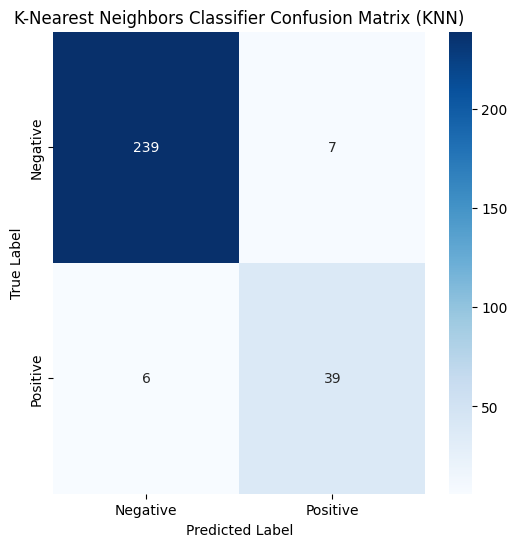

In [127]:
cm_knn = confusion_matrix(y_pred_knn, y_test)
labels = ['Negative','Positive']

plt.figure(figsize=(6,6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('K-Nearest Neighbors Classifier Confusion Matrix (KNN)')
plt.show()

### Decision Tree Classifier

In [99]:
# To avoid bias towards negative values in the model, class weight is set to 'balanced'

dtc = DecisionTreeClassifier(class_weight='balanced')

# fitting the model to the data and predicting on the scaled test dataset
dtc.fit(X_train_scaled, y_train)
y_pred_dtc = dtc.predict(X_test_scaled)

#### Primary Metrics

In [104]:
print(f'Accuracy: {dtc.score(X_test_scaled, y_test):.2f}')

Accuracy: 0.94


In [102]:
print(classification_report(y_test, y_pred_dtc))

              precision    recall  f1-score   support

       False       0.96      0.96      0.96       245
        True       0.80      0.80      0.80        46

    accuracy                           0.94       291
   macro avg       0.88      0.88      0.88       291
weighted avg       0.94      0.94      0.94       291



#### Confusion Matrix

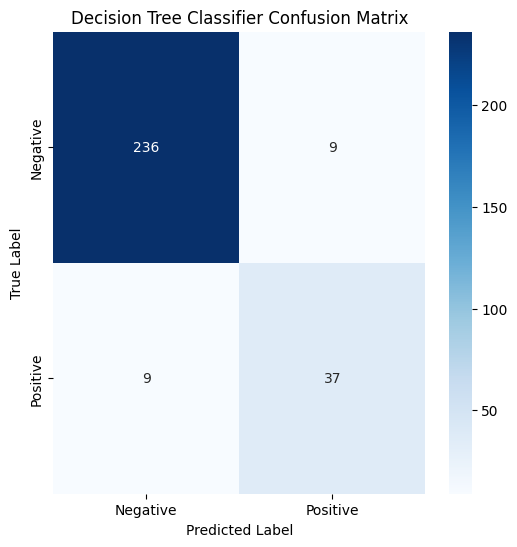

In [126]:
cm_dtc = confusion_matrix(y_pred_dtc, y_test)
labels = ['Negative','Positive']

plt.figure(figsize=(6,6))
sns.heatmap(cm_dtc, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Decision Tree Classifier Confusion Matrix')
plt.show()

### Random Forest Classifier

In [113]:
rfc = RandomForestClassifier(class_weight='balanced')

rfc.fit(X_train_scaled, y_train)
# fitting the model to the data and predicting on the scaled test dataset
rfc.fit(X_train_scaled, y_train)
y_pred_rfc = rfc.predict(X_test_scaled)

#### Primary Metrics 

In [114]:
print(f'Accuracy: {rfc.score(X_test_scaled, y_test):.2f}')

Accuracy: 0.95


In [116]:
print(classification_report(y_test, y_pred_rfc))

              precision    recall  f1-score   support

       False       0.96      0.98      0.97       245
        True       0.90      0.78      0.84        46

    accuracy                           0.95       291
   macro avg       0.93      0.88      0.90       291
weighted avg       0.95      0.95      0.95       291



#### Confusion Matrix

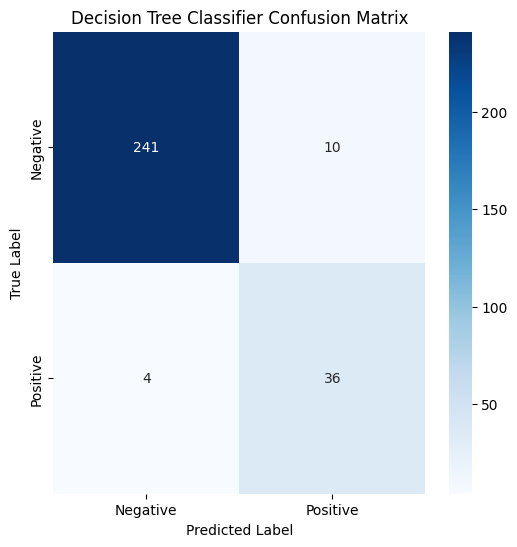

In [125]:
cm_rfc = confusion_matrix(y_pred_rfc, y_test)
labels = ['Negative','Positive']

plt.figure(figsize=(6,6))
sns.heatmap(cm_rfc, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Decision Tree Classifier Confusion Matrix')
plt.show()

### Logistic Regression

In [119]:
lr = LogisticRegression(class_weight='balanced')

# fitting the model to the data and predicting on the scaled test dataset
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

#### Primary Metrics

In [120]:
print(f'Accuracy: {lr.score(X_test_scaled, y_test):.2f}')

Accuracy: 0.88


In [121]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

       False       0.95      0.90      0.92       245
        True       0.59      0.74      0.65        46

    accuracy                           0.88       291
   macro avg       0.77      0.82      0.79       291
weighted avg       0.89      0.88      0.88       291



#### Confusion Matrix

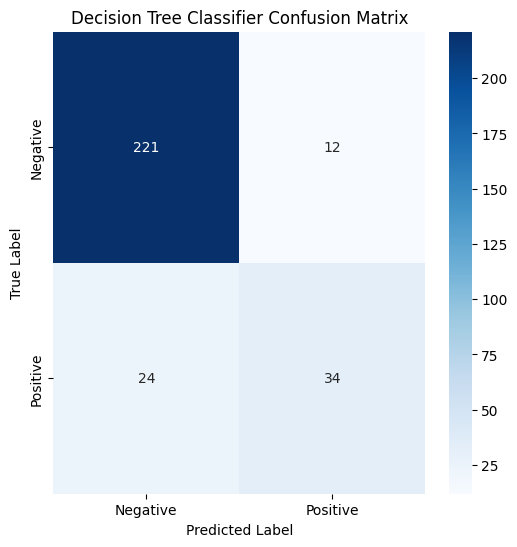

In [124]:
cm_lr = confusion_matrix(y_pred_lr, y_test)
labels = ['Negative','Positive']

plt.figure(figsize=(6,6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Decision Tree Classifier Confusion Matrix')
plt.show()

### ROC & ROC-AUC

ROC = Receiver Operating Characteristic
AUC = Area Under the Curve

AUC = (width of FPR interval) * (height of TPR)

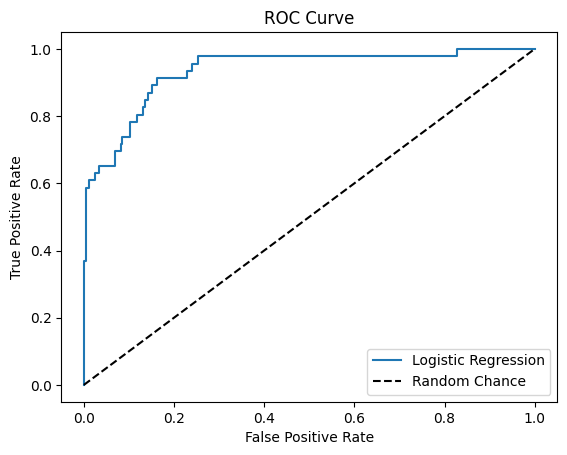

ROC-AUC Score: 0.93


In [83]:
from sklearn.metrics import roc_curve, roc_auc_score

lr.fit(X_train_scaled, y_train)

y_probs = lr.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, threshholds = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1], [0,1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

roc_auc = roc_auc_score(y_test, y_probs)
print(f'ROC-AUC Score: {roc_auc:.2f}')

In [ ]:
from sklearn.metrics import classification_report

lr.fit(X_train_scaled, y_train)

lr.score(X_test_scaled, y_test)

y_pred = lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.95      0.90      0.92       245
        True       0.59      0.74      0.65        46

    accuracy                           0.88       291
   macro avg       0.77      0.82      0.79       291
weighted avg       0.89      0.88      0.88       291



In [78]:
pd.DataFrame(y_train).value_counts()

0    
False    979
True     183
Name: count, dtype: int64

In [129]:
df.head(5)

,ParcelID,WorkType,Contractor,Status,Applied Date,situs_address,year_built,county_code,property_use,lot_size,building_area,land_value,just_value,county,Roof_Material,multiple_re_roofs,Time Since Last Permit,too_close,needs_roof_change,is_shingle,is_tile,is_flat,is_metal,is_other,after_hurricane,year
1192,514226130420,BD Roofing - Com - Replace,Unknown,Approved,1990-10-17,"472 HOLIDAY DR, HALLANDALE BEACH 33009",1995-01-01,16,1,12751,5363,"637,550.00","3,336,890.00",Broward,Other/Unknown,False,"-1,537.00",True,False,False,False,False,False,True,False,1995
1249,514228350040,BD Roofing - Com - Replace,Unknown,Approved,1990-10-30,"912 SW 3 AVE, HALLANDALE BEACH 33009",1959-01-01,16,1,5802,1955,"29,010.00","543,320.00",Broward,Other/Unknown,False,"11,625.00",False,False,False,False,False,False,True,False,1959
1137,514228090040,BD Roofing - Com - Replace,Unknown,Approved,1993-02-17,"913 SW 7 TER, HALLANDALE BEACH 33009",1954-01-01,16,1,6000,1008,"30,000.00","275,030.00",Broward,Other/Unknown,False,"14,292.00",False,False,False,False,False,False,True,True,1954
1188,514221070120,BD Roofing - Com - Replace,Unknown,Approved,1993-04-21,"314 NW 7 CT, HALLANDALE BEACH 33009",1963-01-01,16,1,5841,1754,"29,210.00","385,060.00",Broward,Other/Unknown,False,"11,068.00",False,False,False,False,False,False,True,False,1963
1139,514222040250,BD Roofing - Com - Replace,Unknown,Approved,1993-05-24,"409 NW 2 AVE, HALLANDALE BEACH 33009",1993-01-01,16,1,7500,1664,"37,500.00","531,300.00",Broward,Other/Unknown,False,143.00,False,False,False,False,False,False,True,False,1993
